Retail Demand Forecasting using Walmart Sales Data

Objective:
Forecast weekly sales using historical data and external economic indicators to support inventory planning and demand management.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")


Load Dataset

In [3]:
df = pd.read_csv("Walmart.csv")
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
print(df.shape)
df.info()
df.describe()
df.isnull().sum()


(6435, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

EDA


Sales Trend

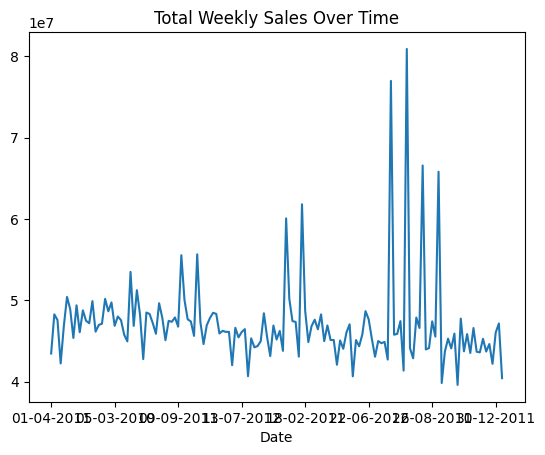

In [5]:
plt.figure()
df.groupby("Date")["Weekly_Sales"].sum().plot()
plt.title("Total Weekly Sales Over Time")
plt.show()


Holiday Impact

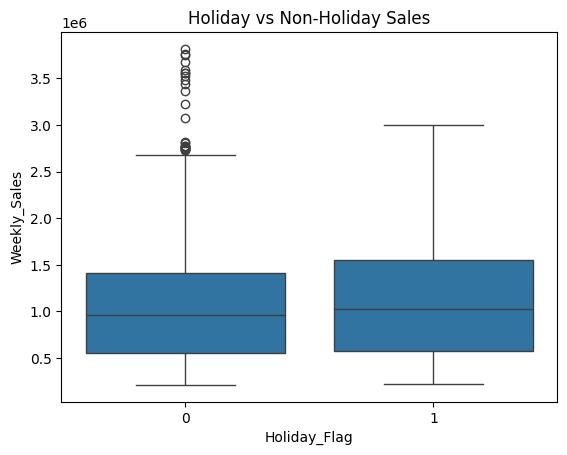

In [6]:
plt.figure()
sns.boxplot(x="Holiday_Flag", y="Weekly_Sales", data=df)
plt.title("Holiday vs Non-Holiday Sales")
plt.show()


Correlation

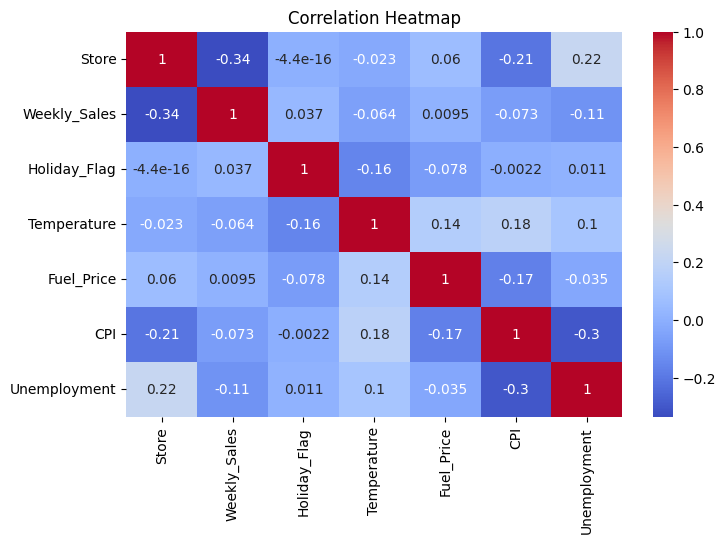

In [9]:
plt.figure(figsize=(8,5))

numeric_df = df.select_dtypes(include=[np.number])
cor = numeric_df.corr()

sns.heatmap(cor, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Feature Engineering

In [11]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week

df.sort_values("Date", inplace=True)

df["Lag_1"] = df["Weekly_Sales"].shift(1)
df["Lag_2"] = df["Weekly_Sales"].shift(2)

df["Rolling_Mean_4"] = df["Weekly_Sales"].rolling(window=4).mean()

df.dropna(inplace=True)


Define target and features

In [12]:
X = df.drop(["Weekly_Sales", "Date"], axis=1)
y = df["Weekly_Sales"]


train-test-split

In [13]:
split_index = int(len(df) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


Random Forest

In [14]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


XGBoost

In [15]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)


Model Evaluation

In [16]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} MAE:", mae)
    print(f"{name} RMSE:", rmse)

evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("XGBoost", y_test, xgb_pred)


Random Forest MAE: 133812.48537035802
Random Forest RMSE: 209783.97209489398
XGBoost MAE: 92708.81055167055
XGBoost RMSE: 127844.50342523454


Prediction Visulaization

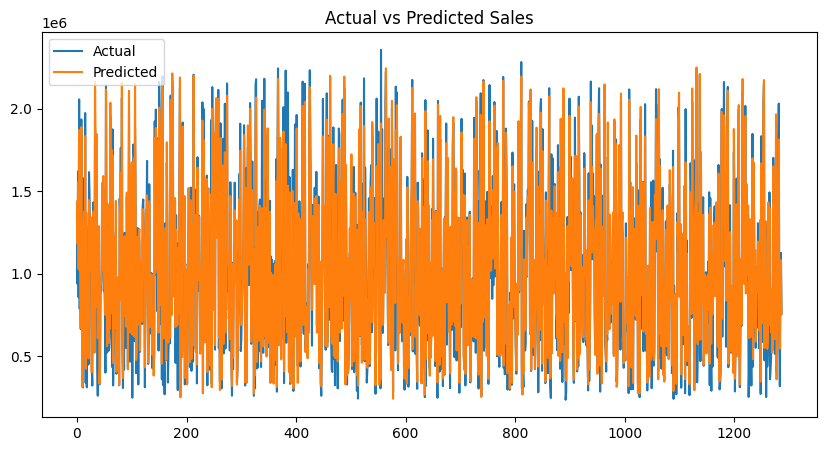

In [17]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(xgb_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()


Feature importance

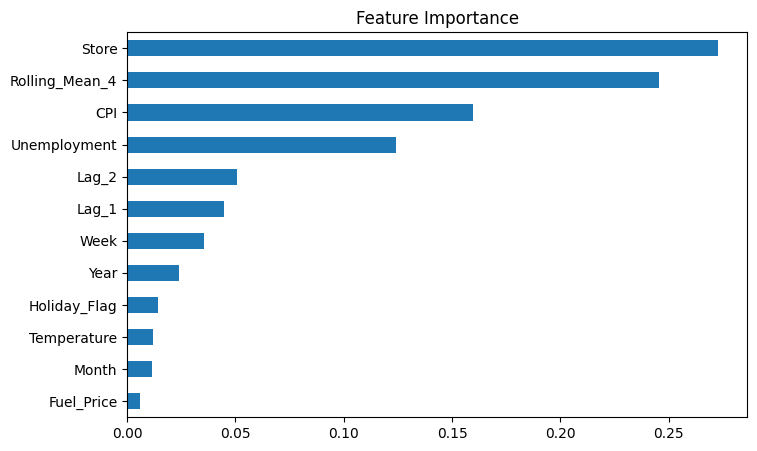

In [18]:
feature_importance = pd.Series(xgb.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance")
plt.show()


hyperparameter tuning

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
rf_pred_tuned = best_rf.predict(X_test)

print("Best Parameters:", grid_search.best_params_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}


In [24]:
evaluate_model("Tuned Random Forest", y_test, rf_pred_tuned)


Tuned Random Forest MAE: 121249.01115373775
Tuned Random Forest RMSE: 192781.82229091335


In [ ]:
#pip install prophet



   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 4.2 MB/s eta 0:00:03
   ------ --------------------------------- 2.1/12.1 MB 5.9 MB/s eta 0:00:02
   ----------- ---------------------------- 3.4/12.1 MB 6.3 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/12.1 MB 6.6 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.1 MB 6.3 MB/s eta 0:00:01
   ------------------------- -------------- 7.6/12.1 MB 6.3 MB/s eta 0:00:01
   ----------------------------- ---------- 8.9/12.1 MB 6.4 MB/s eta 0:00:01
   --------------------------------- ------ 10.2/12.1 MB 6.4 MB/s eta 0:00:01
   -------------------------------------- - 11.5/12.1 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 6.2 MB/s  0:00:02
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   -------------------------------------- - 1.3/1.4 MB 6.7 MB/s eta 0:00:01
   -----------

In [26]:
prophet_df = df[["Date", "Weekly_Sales"]].rename(
    columns={"Date": "ds", "Weekly_Sales": "y"}
)


In [27]:
from prophet import Prophet

model_prophet = Prophet()
model_prophet.fit(prophet_df)


20:15:57 - cmdstanpy - INFO - Chain [1] start processing
20:15:59 - cmdstanpy - INFO - Chain [1] done processing


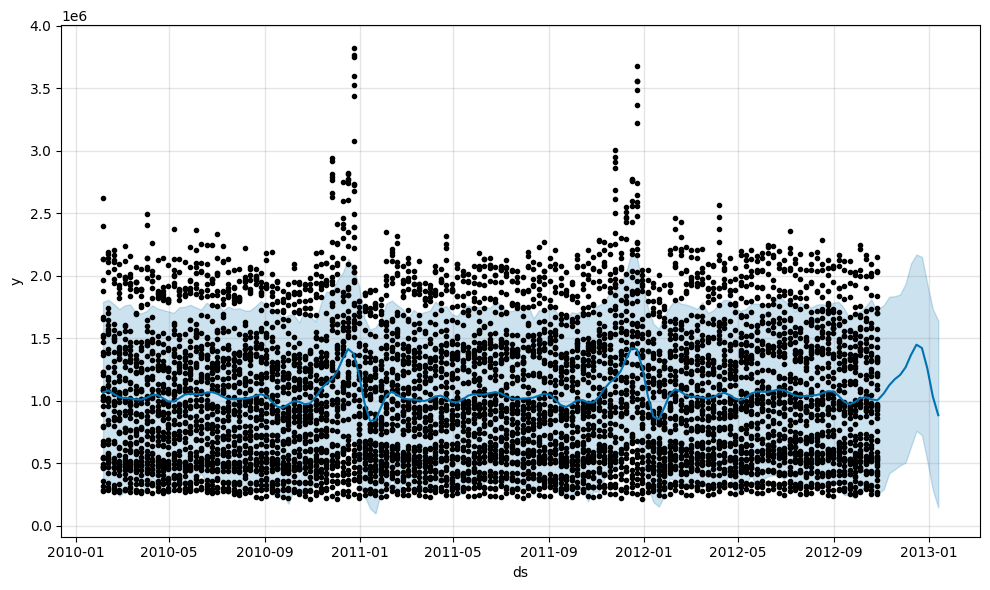

In [28]:
future = model_prophet.make_future_dataframe(periods=12, freq="W")
forecast = model_prophet.predict(future)

model_prophet.plot(forecast)
plt.show()


In [29]:
store_1 = df[df["Store"] == 1]

X_store = store_1.drop(["Weekly_Sales", "Date"], axis=1)
y_store = store_1["Weekly_Sales"]

split_index = int(len(store_1) * 0.8)

X_train_s, X_test_s = X_store[:split_index], X_store[split_index:]
y_train_s, y_test_s = y_store[:split_index], y_store[split_index:]

rf_store = RandomForestRegressor(n_estimators=200, random_state=42)
rf_store.fit(X_train_s, y_train_s)

pred_store = rf_store.predict(X_test_s)

evaluate_model("Store 1 RF", y_test_s, pred_store)


Store 1 RF MAE: 121300.7251431017
Store 1 RF RMSE: 143602.30608705006


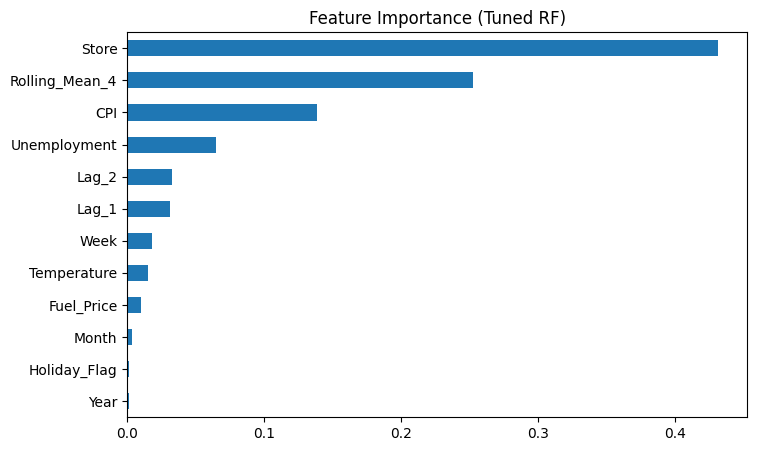

In [30]:
importance = pd.Series(best_rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance (Tuned RF)")
plt.show()


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate MAE
mae = mean_absolute_error(y_test, xgb_pred)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

# Calculate MAPE
mape = np.mean(np.abs((y_test - xgb_pred) / y_test)) * 100

# Convert to accuracy
accuracy = 100 - mape

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("Forecasting Accuracy:", accuracy)


MAE: 92708.81055167055
RMSE: 127844.50342523454
MAPE: 11.90367655528163
Forecasting Accuracy: 88.09632344471837
